In [1]:
import zarr
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [2]:
o = zarr.open_group('/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/runs/harps/outputs/zarr/synthesized_spectra.zarr')

In [3]:
o.tree()

/
├── continuum (9825, 310001) float32
├── flux (9825, 310001) float32
├── global_index (9825,) int64
├── model_id (9825,) uint64
├── mu_selected (9825,) float32
├── mu_selected_index (9825,) int16
├── param_names (10,) <U32
├── params (9825, 10) float32
├── physics_hash () <U64
├── provenance
│   ├── atmosphere_manifest.json () object
│   ├── canonical_config.yaml () object
│   ├── environment.txt () object
│   ├── linelist_manifest.json () object
│   ├── software_manifest.json () object
│   └── synthesis_config.yaml () object
├── schema_version () <U16
└── wavelength (310001,) float32

In [6]:
import json

prov = o['provenance']

# Read and print JSONs from provenance
json_files = [
    "atmosphere_manifest.json",
    "linelist_manifest.json",
    "software_manifest.json"
]

for fname in json_files:
    v = prov[fname]
    json_bytes = v[()]  # get the scalar value from the 0-d array
    if isinstance(json_bytes, bytes):
        json_str = json_bytes.decode("utf-8")
    else:
        json_str = str(json_bytes)
    try:
        parsed = json.loads(json_str)
    except Exception as e:
        print(f"Could not parse {fname}: {e}")
        continue
    print(f"Contents of {fname}:\n{json.dumps(parsed, indent=2)}\n")

Contents of atmosphere_manifest.json:
{
  "geometry": "",
  "path": "/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/input_files/model_atmospheres/1D/marcs_standard_comp",
  "sha256": "c82109845f2018d59916d6f500099458edd17a363fc6588298ae99586e9ef3a6",
  "version": "sha256:c82109845f2018d5"
}

Contents of linelist_manifest.json:
{
  "files": [
    {
      "exists": true,
      "path": "/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/input_files/linelists/nlte_ges_linelist_jmg6may2025_I_II",
      "sha256": "7ea3064efcc94cbde9544e10e80252f374206028c2d19fdadf981b0cb4a4291b",
      "size_bytes": 15353679
    },
    {
      "exists": true,
      "path": "/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/input_files/linelists/Hlinedata",
      "sha256": "c45bd89eabfb850a90168184146c094d2fbfd9b124ad9e1bd93075bf1e01cc1e",
      "size_bytes": 9705
    },
    {
      "exists": true,
      "path": "/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/input_files/linelists/vald-3700-3800.list",
      "sha256": "22e9

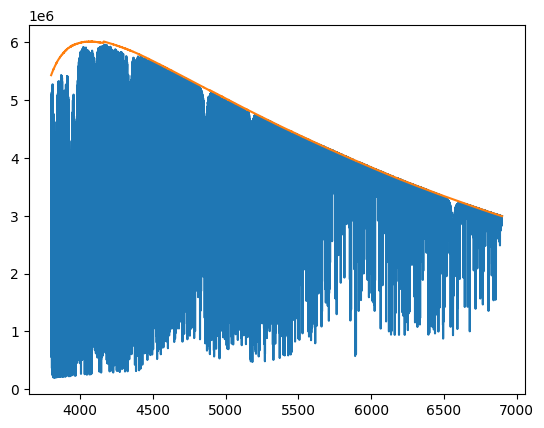

In [10]:
plt.plot(o['wavelength'][:], o['flux'][0]);
plt.plot(o['wavelength'][:], o['continuum'][0]);